### Описание признаков датасета (Automobile Data)

Этот набор данных содержит технические характеристики автомобилей и их стоимость. Ниже приведена расшифровка каждой переменной:

| Переменная | Описание |
| :--- | :--- |
| **symboling** | Показатель страхового риска (от -3 до +3). Чем выше число, тем рискованнее автомобиль. |
| **normalized-losses** | Относительная средняя выплата по страховке за год. |
| **make** | Марка автомобиля (Toyota, Nissan, Volvo и др.). |
| **fuel-type** | Тип топлива (gas — бензин, diesel — дизель). |
| **aspiration** | Тип впуска двигателя (std — стандартный, turbo — турбонаддув). |
| **num-of-doors** | Количество дверей (two — две, four — четыре). |
| **body-style** | Тип кузова (sedan, hatchback, wagon, hardtop, convertible). |
| **drive-wheels** | Привод (fwd — передний, rwd — задний, 4wd — полный). |
| **engine-location** | Расположение двигателя (front — спереди, rear — сзади). |
| **wheel-base** | Колесная база (расстояние между осями колес). |
| **length, width, height** | Габариты автомобиля (длина, ширина, высота). |
| **curb-weight** | Снаряженная масса (вес без пассажиров). |
| **engine-type** | Тип конструкции двигателя (ohc, ohcv, dohc и др.). |
| **num-of-cylinders** | Количество цилиндров. |
| **engine-size** | Объем двигателя. |
| **fuel-system** | Система подачи топлива (mpfi, 2bbl, idi и др.). |
| **bore / stroke** | Диаметр цилиндра и ход поршня. |
| **compression-ratio** | Степень сжатия. |
| **horsepower** | Мощность в лошадиных силах. |
| **peak-rpm** | Обороты двигателя при пиковой мощности. |
| **city / highway-mpg** | Расход топлива в городе и на шоссе (миль на галлон). |
| **price** | **Целевая переменная:** Стоимость автомобиля. |

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
np.set_printoptions(suppress=True)

In [3]:
path = str(Path.cwd().parent) + '\\res\\data\\'

data = pd.read_csv(path + 'Automobile_data.csv')

In [4]:
df = data.iloc[:, np.r_[1, 9:14, 16, 18:26]]
df.head()

,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,?,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495
1,?,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500
2,?,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500
3,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.4,10.0,102,5500,24,30,13950
4,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
# Обработаем пропуски
(df == '?').sum()

normalized-losses    41
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-size           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [6]:
df = df[
    (df['normalized-losses'] != '?') & \
    (df['bore'] != '?') & \
    (df['stroke'] != '?') & \
    (df['horsepower'] != '?') & \
    (df['peak-rpm'] != '?') & \
    (df['price'] != '?')
    ]

Обработаны пропуски в данных

In [7]:
# Обработаем типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 3 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   normalized-losses  160 non-null    object 
 1   wheel-base         160 non-null    float64
 2   length             160 non-null    float64
 3   width              160 non-null    float64
 4   height             160 non-null    float64
 5   curb-weight        160 non-null    int64  
 6   engine-size        160 non-null    int64  
 7   bore               160 non-null    object 
 8   stroke             160 non-null    object 
 9   compression-ratio  160 non-null    float64
 10  horsepower         160 non-null    object 
 11  peak-rpm           160 non-null    object 
 12  city-mpg           160 non-null    int64  
 13  highway-mpg        160 non-null    int64  
 14  price              160 non-null    object 
dtypes: float64(5), int64(4), object(6)
memory usage: 20.0+ KB


Некоторые из количественных столбцов, имеют тип object. Необходимо обработать типы данных

In [8]:
# Так как среди данных есть и float, и int, то приведем все данные к виду float
df = df.astype(float)


### 1. Проверка и обработка данных

In [9]:
# Обработка нулей - не требуется
df.isnull().sum()

normalized-losses    0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

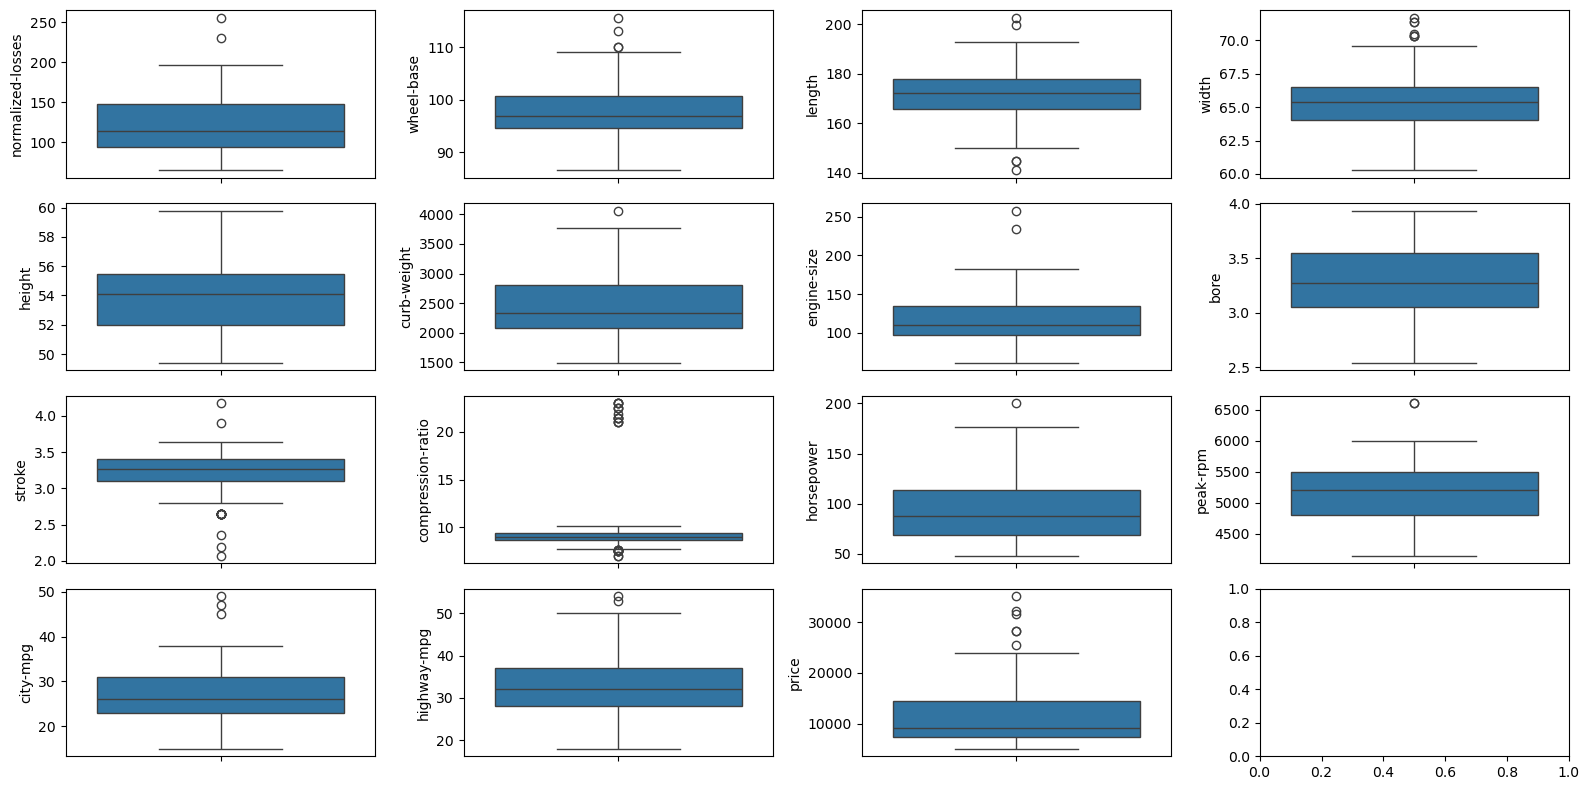

In [10]:
# Проверим на наличие выбросов - найдены выбросы
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes_lst = axes.flatten()
cols = df.columns

for i, col_name in enumerate(cols):
        
    sns.boxplot(df[col_name], ax=axes_lst[i])

plt.tight_layout()
plt.show()

In [11]:
def ejection(df, col):
    q25 = np.percentile(df[col], 25)
    q75 = np.percentile(df[col], 75)
    iqr = q75 - q25
    
    ejection_l = q25 - 1.5 * iqr
    ejection_h = q75 + 1.5 * iqr
    
    df_good = df[(df[col] >= ejection_l) & (df[col] <= ejection_h)]
    ejection_percent = (len(df) - len(df_good)) / len(df)
    
    print(f'Процент выбросов по {col}: ', ejection_percent)
    
    return df_good

In [12]:
# Выбросы найдены по следующим столбцам:
ejection_col = ['normalized-losses',
                'wheel-base',
                'length',
                'width',
                'curb-weight',
                'engine-size',
                'stroke',
                'compression-ratio',
                'horsepower',
                'peak-rpm',
                'city-mpg',
                'highway-mpg',
                'price'
]


In [13]:
# Обработаем выбросы
df_good = df.copy()

for col in ejection_col:
    df_good = ejection(df_good, col)
    

Процент выбросов по normalized-losses:  0.0125
Процент выбросов по wheel-base:  0.012658227848101266
Процент выбросов по length:  0.019230769230769232
Процент выбросов по width:  0.0392156862745098
Процент выбросов по curb-weight:  0.0
Процент выбросов по engine-size:  0.07482993197278912
Процент выбросов по stroke:  0.022058823529411766
Процент выбросов по compression-ratio:  0.16541353383458646
Процент выбросов по horsepower:  0.02702702702702703
Процент выбросов по peak-rpm:  0.018518518518518517
Процент выбросов по city-mpg:  0.0
Процент выбросов по highway-mpg:  0.0
Процент выбросов по price:  0.10377358490566038


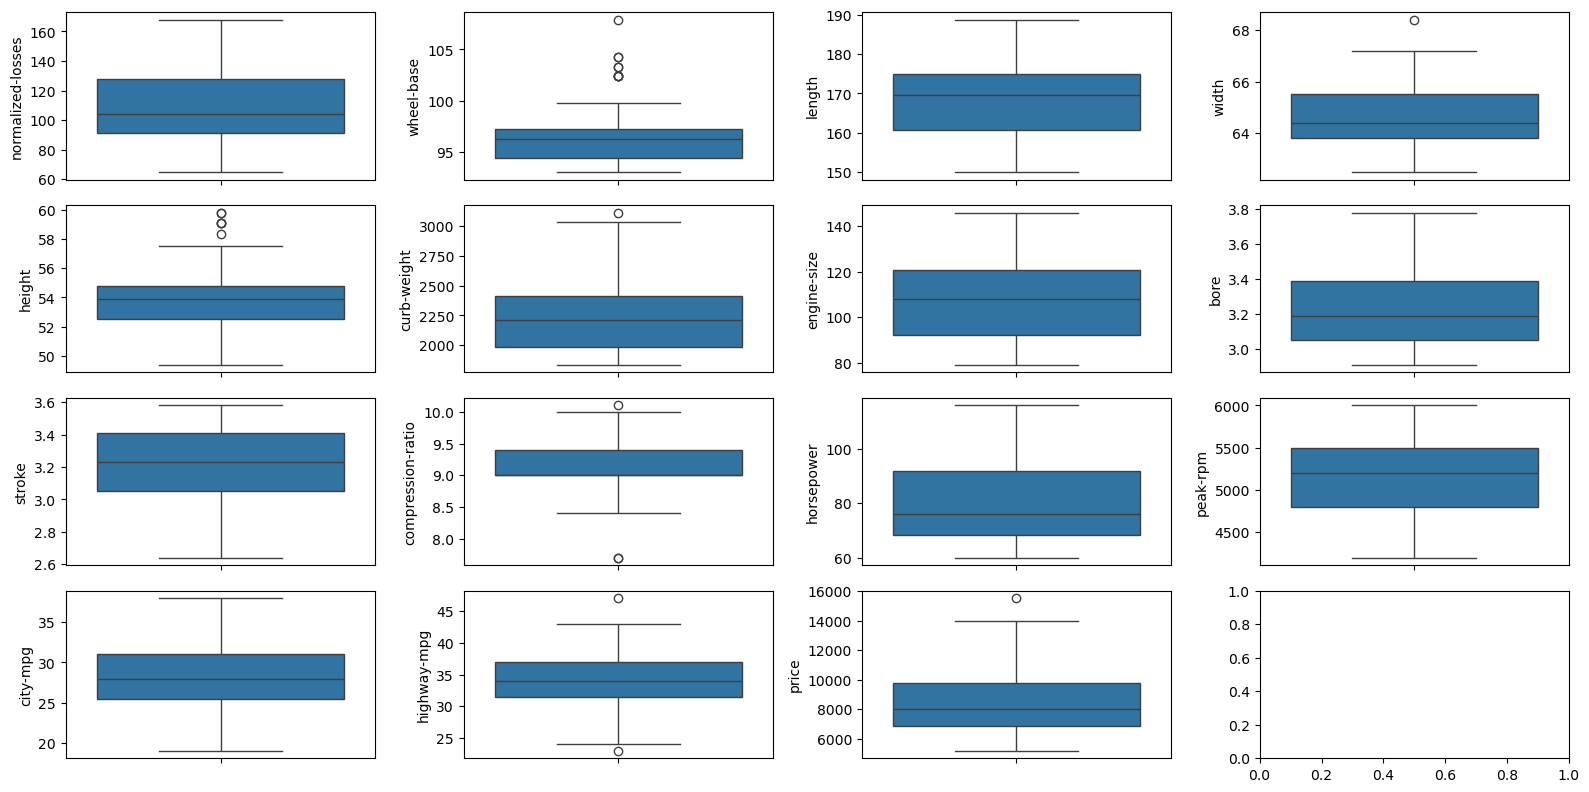

In [14]:
# Большая часть выбросов исключена
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes_lst = axes.flatten()
cols = df.columns

for i, col_name in enumerate(cols):
        
    sns.boxplot(df_good[col_name], ax=axes_lst[i])

plt.tight_layout()
plt.show()

<Axes: >

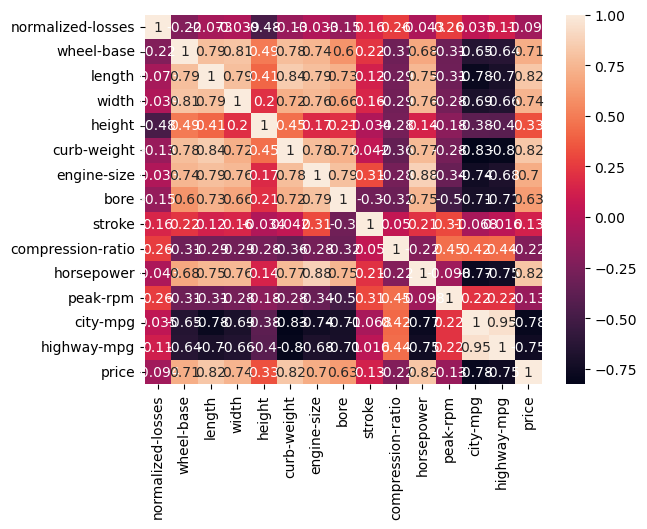

In [15]:
# Проверим на наличие линейных связей
sns.heatmap(df_good.corr(), annot=True)

Таким образом, видно, средим многих пар видна высокая корелляция, как положительная, так и отрицательная

### 2. Проверка применимости PCA

#### 2.1 Тест сферичности Бартлетта

In [16]:
n = df_good.shape[0]
p = df_good.shape[1]

if n / p > 5:
    print('Тест сферичности Бартлетта не стоит применять, всегда будет значим')

else:
    print('Можно применять тест сферичности Бартлетта')

Тест сферичности Бартлетта не стоит применять, всегда будет значим


#### 2.2 Критерий КМО

In [17]:
from factor_analyzer.factor_analyzer import calculate_kmo

kmo_all, kmo_model = calculate_kmo(df_good)

print(f'Общий КМО: {kmo_model}', f'Частные КМО: {kmo_all}', sep='\n')

Общий КМО: 0.788585840522297
Частные КМО: [0.57151663 0.90092393 0.89521485 0.90659683 0.72319388 0.81801421
 0.6825539  0.69799561 0.16269935 0.7729749  0.86502447 0.57422644
 0.86448482 0.84747799 0.87936476]


Общий КМО > 0.6, следовательно, PCA применим

### 3. Метод главных компонент (PCA)

In [18]:
from sklearn.preprocessing import StandardScaler

# Стандартизируем данные
sc = StandardScaler()
df_sc = sc.fit_transform(df_good)

df_sc = pd.DataFrame(df_sc)
df_sc.columns = df_sc.columns + 1
df_sc.index = df_sc.index + 1

df_sc.head()


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
1,1.955016,1.104714,0.903296,1.224379,0.231924,0.340919,0.154761,-0.236113,0.687837,2.284962,1.266065,0.930537,-1.064426,-0.946163,2.585480
2,-0.488754,-0.704143,-1.462308,-1.109121,-0.823813,-1.273392,-1.049304,-0.901959,-0.395634,1.292409,-0.736452,0.689004,2.396910,2.096835,-1.013424
3,-1.118210,-0.704143,-1.130894,-1.109121,-0.823813,-1.151360,-1.049304,-0.901959,-0.395634,1.292409,-0.736452,0.689004,2.396910,2.096835,-0.881785
4,0.251782,-0.977178,-1.302315,-0.929621,-1.374632,-1.266418,-1.049304,-1.151652,0.052699,0.820946,-0.861609,0.930537,2.149672,1.628682,-1.353333
5,0.251782,-0.977178,-1.302315,-0.929621,-1.374632,-1.266418,-1.049304,-1.151652,0.052699,0.796132,-0.861609,0.930537,0.666242,0.926451,-0.974872


In [19]:
# Найдем ковариационную матрицу
df_corr = df_sc.corr()
df_corr

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
1,1.000000,-0.223409,-0.072554,-0.038996,-0.479249,-0.130480,-0.033137,-0.147014,0.157293,0.263018,-0.042698,0.262196,0.035192,0.111961,-0.093538
2,-0.223409,1.000000,0.787267,0.808904,0.489010,0.780349,0.743324,0.596912,0.224548,-0.310020,0.679600,-0.313668,-0.651715,-0.635876,0.714234
3,-0.072554,0.787267,1.000000,0.791754,0.409541,0.843593,0.792256,0.728921,0.124356,-0.289732,0.754718,-0.305484,-0.775921,-0.704544,0.823338
4,-0.038996,0.808904,0.791754,1.000000,0.204153,0.720112,0.758551,0.664870,0.157032,-0.294723,0.761758,-0.280214,-0.694507,-0.663076,0.738650
5,-0.479249,0.489010,0.409541,0.204153,1.000000,0.450717,0.172933,0.206632,-0.033758,-0.277524,0.142741,-0.184071,-0.383879,-0.403969,0.334769
6,-0.130480,0.780349,0.843593,0.720112,0.450717,1.000000,0.781230,0.724414,0.041929,-0.357797,0.770436,-0.279346,-0.825846,-0.802479,0.823613
7,-0.033137,0.743324,0.792256,0.758551,0.172933,0.781230,1.000000,0.794485,0.309880,-0.283059,0.875143,-0.338160,-0.743020,-0.683331,0.701657
8,-0.147014,0.596912,0.728921,0.664870,0.206632,0.724414,0.794485,1.000000,-0.301773,-0.324831,0.746451,-0.501721,-0.712701,-0.709948,0.634620
9,0.157293,0.224548,0.124356,0.157032,-0.033758,0.041929,0.309880,-0.301773,1.000000,0.050303,0.208623,0.306077,-0.067586,0.016353,0.127224
10,0.263018,-0.310020,-0.289732,-0.294723,-0.277524,-0.357797,-0.283059,-0.324831,0.050303,1.000000,-0.216607,0.448535,0.423145,0.437725,-0.221295


In [20]:
# Найдем собственные числа и собсственные векторы
eigenvalues, eigenvectors = np.linalg.eig(df_corr)

print(f'Собственные значения:\n {eigenvalues.round(4)}', f'\nСобственные векторы:\n {eigenvectors}', sep='\n')

Собственные значения:
 [8.2079 1.8998 1.2703 0.9154 0.7789 0.5691 0.3739 0.2525 0.2331 0.1661
 0.1342 0.0085 0.0381 0.0564 0.0959]

Собственные векторы:
 [[-0.05843466 -0.47331879 -0.41191323 -0.02540444 -0.32982491  0.63724349
  -0.03498123 -0.03814495 -0.15419669  0.02909101  0.24141964 -0.01191161
  -0.03710241 -0.01550847  0.0053884 ]
 [ 0.29735699 -0.00719771  0.2154806  -0.13201077  0.2496758   0.22046376
   0.28461147 -0.31800196 -0.08108979  0.4424939   0.07992112 -0.01125368
   0.10560406 -0.08123919 -0.57267321]
 [ 0.31691333 -0.05574717  0.02195895  0.02701509  0.12285605  0.2449303
   0.06607324  0.34088763 -0.17113472 -0.49359477 -0.48673583  0.07070032
  -0.10608489 -0.34118685 -0.23894772]
 [ 0.29718085 -0.11535638 -0.05416554 -0.13459832  0.16760518  0.0678511
   0.58099181 -0.36469486  0.19069105 -0.27095861 -0.034515   -0.00152142
  -0.0183525   0.14447299  0.49182542]
 [ 0.14900114  0.32867307  0.55553649  0.25131013 -0.04498604  0.41780417
  -0.23466983 -0.13301097 

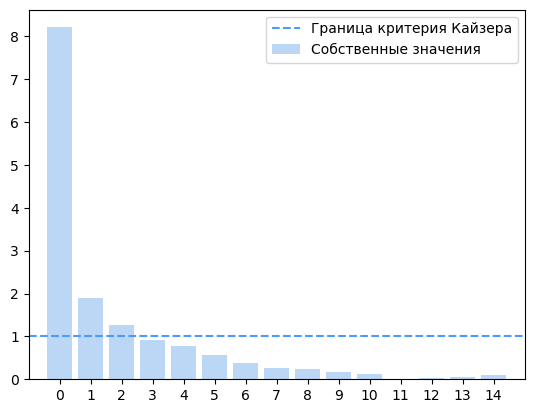

In [21]:
# Отбор факторов
sns.barplot(eigenvalues, color="#b3d5ff", label='Собственные значения')
plt.plot([-1, p+1], [1, 1], '--', color="#499bff" ,label='Граница критерия Кайзера')

plt.xlim((-1, p))
plt.legend()
plt.show()


Видно, что певые три компоненты имеют собственные значения больше 1, следовательно, их стоит оставить. В целях визуализации и построения biplot оставим первые две главные компоненты.

In [22]:
# Объясненная сумма дисперсии
eigenvalues / sum(eigenvalues) * 100

# Накопленные доли
np.cumsum(eigenvalues) / sum(eigenvalues) * 100

array([ 54.71949381,  67.38498086,  75.8535968 ,  81.95618202,
        87.14884796,  90.94288913,  93.43546262,  95.11861637,
        96.67229689,  97.77981669,  98.6741793 ,  98.73082343,
        98.98470608,  99.36039554, 100.        ])

In [23]:
# Найдем проекции данных на новые компоненты
score = df_sc @ eigenvectors
score.columns = [f'PC_{i}' for i in score.columns]
score

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14
1,2.341790,-3.258679,0.190900,1.790894,0.498287,1.291573,0.490621,0.326604,1.296835,-0.081767,1.036302,0.033289,0.054430,-0.053331,-0.321432
2,-4.305196,-0.034413,0.100479,0.150785,1.602510,-0.571012,0.428292,0.163739,-0.594748,0.366598,0.395457,0.016380,-0.106551,-0.039642,0.006703
3,-4.084198,0.228174,0.379936,0.218107,1.848732,-0.882580,0.497161,0.413797,-0.540692,0.261678,0.090529,0.035490,-0.130276,-0.095092,-0.037601
4,-4.344639,-0.711046,-0.219096,-0.317468,0.681024,-0.453284,0.497094,-0.015944,-0.495045,0.253258,-0.019972,0.024959,-0.319190,-0.165493,0.055537
5,-3.547283,-0.788037,-0.248972,0.095565,-0.121598,-0.561077,0.188753,-0.175315,0.364918,0.153587,-0.196545,0.030054,0.273948,0.015893,-0.231977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.616450,0.000859,1.243098,-0.218883,0.042330,-0.087862,0.090601,-0.385660,-0.043481,-0.564289,-0.084694,0.010743,0.203307,-0.061964,0.247347
92,0.729867,-0.017185,1.260264,-0.162373,0.036711,-0.068842,0.113469,-0.241747,-0.045102,-0.427068,-0.108884,-0.017222,0.189053,-0.010489,0.329721
93,1.029545,-1.438451,1.363636,1.632629,1.250898,-0.298343,-0.458318,-0.339708,0.803488,-0.316930,0.208900,-0.066478,0.186986,-0.386308,0.402740
94,6.239209,-1.195756,0.308819,1.653933,1.662079,0.203790,0.338870,-0.407517,-0.773102,0.279005,-0.194459,0.107658,-0.134050,0.269974,-0.190676


In [25]:
eigenvectors[0]

array([-0.05843466, -0.47331879, -0.41191323, -0.02540444, -0.32982491,
        0.63724349, -0.03498123, -0.03814495, -0.15419669,  0.02909101,
        0.24141964, -0.01191161, -0.03710241, -0.01550847,  0.0053884 ])

In [27]:
# Отобразим матрицу нагрузок: показывает связь между исходными переменными и главными компонентами
components = pd.DataFrame(eigenvectors, columns=[f'eigenvectors_{i}' for i in range(p)], index=df_good.columns)
components

,eigenvectors_0,eigenvectors_1,eigenvectors_2,eigenvectors_3,eigenvectors_4,eigenvectors_5,eigenvectors_6,eigenvectors_7,eigenvectors_8,eigenvectors_9,eigenvectors_10,eigenvectors_11,eigenvectors_12,eigenvectors_13,eigenvectors_14
normalized-losses,-0.058435,-0.473319,-0.411913,-0.025404,-0.329825,0.637243,-0.034981,-0.038145,-0.154197,0.029091,0.241420,-0.011912,-0.037102,-0.015508,0.005388
wheel-base,0.297357,-0.007198,0.215481,-0.132011,0.249676,0.220464,0.284611,-0.318002,-0.081090,0.442494,0.079921,-0.011254,0.105604,-0.081239,-0.572673
length,0.316913,-0.055747,0.021959,0.027015,0.122856,0.244930,0.066073,0.340888,-0.171135,-0.493595,-0.486736,0.070700,-0.106085,-0.341187,-0.238948
width,0.297181,-0.115356,-0.054166,-0.134598,0.167605,0.067851,0.580992,-0.364695,0.190691,-0.270959,-0.034515,-0.001521,-0.018353,0.144473,0.491825
height,0.149001,0.328673,0.555536,0.251310,-0.044986,0.417804,-0.234670,-0.133011,-0.195158,-0.221325,0.334534,0.013385,-0.007690,0.038380,0.218983
curb-weight,0.321385,0.000361,0.037625,0.124909,-0.037841,0.112991,-0.043497,0.256046,-0.183489,0.615779,-0.372648,-0.172101,-0.016672,0.002178,0.465214
engine-size,0.308225,-0.154698,-0.090737,-0.239373,0.171877,-0.130862,-0.381973,-0.094775,-0.237478,0.014242,-0.002234,0.684862,-0.008166,0.291313,0.058405
bore,0.289276,0.136594,-0.369087,0.103961,0.163910,-0.138235,-0.195474,-0.151814,-0.317823,-0.171745,0.050274,-0.565089,-0.149274,0.378459,-0.159751
stroke,0.032221,-0.468490,0.471521,-0.526569,-0.020377,-0.043443,-0.272810,0.051577,0.143059,-0.076757,-0.038085,-0.383252,-0.126862,0.096986,0.017087
compression-ratio,-0.149672,-0.345488,-0.016998,0.480920,0.626055,0.146172,-0.281163,-0.122324,0.328818,0.035180,-0.079485,-0.024315,0.010282,-0.032921,0.043357


In [36]:
# Главные факторы - нормированные главные компоненты
# Так как данные уже были стандартизированы, то их среднее - 0, осталось только сделать единичную дисперсию)

factors = score / np.sqrt(eigenvalues)
factors.columns = [f'{col}_norm' for col in score.columns]
factors

,PC_0_norm,PC_1_norm,PC_2_norm,PC_3_norm,PC_4_norm,PC_5_norm,PC_6_norm,PC_7_norm,PC_8_norm,PC_9_norm,PC_10_norm,PC_11_norm,PC_12_norm,PC_13_norm,PC_14_norm
1,0.817394,-2.364205,0.169377,1.871834,0.564597,1.712073,0.802374,0.650002,2.686323,-0.200611,2.829332,0.361139,0.278918,-0.224657,-1.037738
2,-1.502714,-0.024967,0.089150,0.157600,1.815766,-0.756918,0.700439,0.325871,-1.231989,0.899434,1.079685,0.177706,-0.546006,-0.166994,0.021642
3,-1.425575,0.165542,0.337100,0.227964,2.094755,-1.169924,0.813070,0.823530,-1.120014,0.642015,0.247164,0.385019,-0.667576,-0.400574,-0.121393
4,-1.516481,-0.515871,-0.194394,-0.331816,0.771652,-0.600860,0.812960,-0.031732,-1.025460,0.621358,-0.054528,0.270771,-1.635636,-0.697140,0.179300
5,-1.238167,-0.571729,-0.220901,0.099884,-0.137780,-0.743749,0.308692,-0.348909,0.755908,0.376819,-0.536610,0.326050,1.403800,0.066950,-0.748933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.215170,0.000624,1.102944,-0.228776,0.047963,-0.116467,0.148171,-0.767534,-0.090068,-1.384460,-0.231233,0.116551,1.041816,-0.261025,0.798556
92,0.254757,-0.012468,1.118175,-0.169711,0.041597,-0.091255,0.185569,-0.481119,-0.093427,-1.047794,-0.297278,-0.186832,0.968771,-0.044186,1.064499
93,0.359359,-1.043611,1.209892,1.706416,1.417363,-0.395475,-0.749544,-0.676081,1.664382,-0.777575,0.570343,-0.721201,0.958180,-1.627323,1.300241
94,2.177774,-0.867533,0.274001,1.728683,1.883262,0.270138,0.554196,-0.811032,-1.601439,0.684526,-0.530917,1.167947,-0.686920,1.137265,-0.615594


In [37]:
from scipy.stats import pearsonr

loadings = np.array([[pearsonr(df_sc.iloc[:, i], factors.iloc[:, j])[0] for j in range(p)] for i in range(p)])
pd.DataFrame(loadings, columns=factors.columns, index=df.columns)

,PC_0_norm,PC_1_norm,PC_2_norm,PC_3_norm,PC_4_norm,PC_5_norm,PC_6_norm,PC_7_norm,PC_8_norm,PC_9_norm,PC_10_norm,PC_11_norm,PC_12_norm,PC_13_norm,PC_14_norm
normalized-losses,-0.167412,-0.652395,-0.464256,-0.024306,-0.291088,0.480731,-0.021390,-0.019167,-0.074439,0.011857,0.088425,-0.001098,-0.007240,-0.003682,0.001669
wheel-base,0.851912,-0.009921,0.242862,-0.126302,0.220352,0.166316,0.174029,-0.159785,-0.039146,0.180355,0.029273,-0.001037,0.020608,-0.019285,-0.177381
length,0.907940,-0.076839,0.024749,0.025847,0.108427,0.184773,0.040401,0.171285,-0.082616,-0.201183,-0.178277,0.006517,-0.020702,-0.080994,-0.074012
width,0.851408,-0.159000,-0.061048,-0.128778,0.147920,0.051186,0.355255,-0.183247,0.092057,-0.110439,-0.012642,-0.000140,-0.003581,0.034296,0.152339
height,0.426880,0.453023,0.626130,0.240443,-0.039703,0.315188,-0.143492,-0.066834,-0.094213,-0.090209,0.122530,0.001234,-0.001501,0.009111,0.067828
curb-weight,0.920752,0.000497,0.042406,0.119508,-0.033397,0.085239,-0.026597,0.128655,-0.088580,0.250984,-0.136490,-0.015864,-0.003254,0.000517,0.144097
engine-size,0.883049,-0.213227,-0.102267,-0.229022,0.151690,-0.098721,-0.233562,-0.047621,-0.114644,0.005805,-0.000818,0.063129,-0.001594,0.069154,0.018091
bore,0.828761,0.188273,-0.415988,0.099466,0.144659,-0.104283,-0.119525,-0.076281,-0.153430,-0.070001,0.018414,-0.052088,-0.029130,0.089842,-0.049482
stroke,0.092310,-0.645739,0.531439,-0.503800,-0.017984,-0.032773,-0.166813,0.025916,0.069062,-0.031285,-0.013949,-0.035327,-0.024757,0.023023,0.005293
compression-ratio,-0.428801,-0.476200,-0.019158,0.460124,0.552527,0.110271,-0.171920,-0.061464,0.158738,0.014339,-0.029113,-0.002241,0.002007,-0.007815,0.013430


### 4. Реализация через sklearn

In [38]:
from sklearn.decomposition import PCA

# Создадим модель
pca = PCA(n_components=2)

# Применим к данным
score = pca.fit_transform(df_sc)

score

array([[ 2.34178967,  3.2586794 ],
       [-4.30519626,  0.03441329],
       [-4.08419842, -0.22817371],
       [-4.3446387 ,  0.71104565],
       [-3.54728348,  0.78803709],
       [-3.54502707,  1.33491977],
       [-3.45428621,  1.36286237],
       [-3.32339344,  1.41825924],
       [ 3.0804108 , -0.86589189],
       [-5.32788222,  0.2318352 ],
       [-3.08079296,  1.03990023],
       [-2.97722   ,  1.07612668],
       [-2.01307137,  1.04941776],
       [-1.91105058, -0.14088083],
       [ 0.01172873,  1.45043309],
       [ 0.24240623,  1.52285957],
       [ 0.6097953 ,  1.06933904],
       [ 0.17282284,  0.87731211],
       [ 2.24979238,  1.51752259],
       [ 1.15613226,  2.00904469],
       [-2.3731017 , -1.06076416],
       [-2.80961369, -0.97493053],
       [-2.70409279, -0.93264914],
       [-2.41414689, -0.73195592],
       [-2.24843424, -0.7180966 ],
       [ 2.31145554,  0.24454077],
       [ 2.44291038, -0.29355055],
       [ 2.5612509 ,  0.35025998],
       [ 2.69270574,

In [39]:
pd.DataFrame(pca.components_.T)

,0,1
0,-0.058435,0.473319
1,0.297357,0.007198
2,0.316913,0.055747
3,0.297181,0.115356
4,0.149001,-0.328673
5,0.321385,-0.000361
6,0.308225,0.154698
7,0.289276,-0.136594
8,0.032221,0.468490
9,-0.149672,0.345488


### 5. Наблюдения в пространстве главных компонент

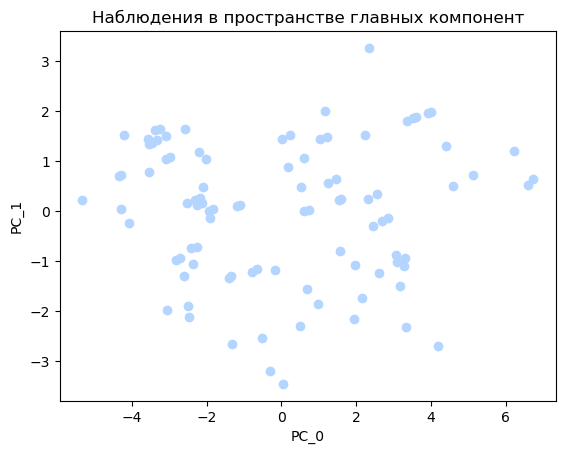

In [45]:
plt.scatter(score[:, 0], score[:, 1], color='#b3d5ff')

plt.xlabel('PC_0')
plt.ylabel('PC_1')
plt.title('Наблюдения в пространстве главных компонент')

plt.show()

Видно, что главные компоненты распределены в виде некоторого "облака" и не образуют зависимостей.

### 6. Признаки в пространстве главных компонент

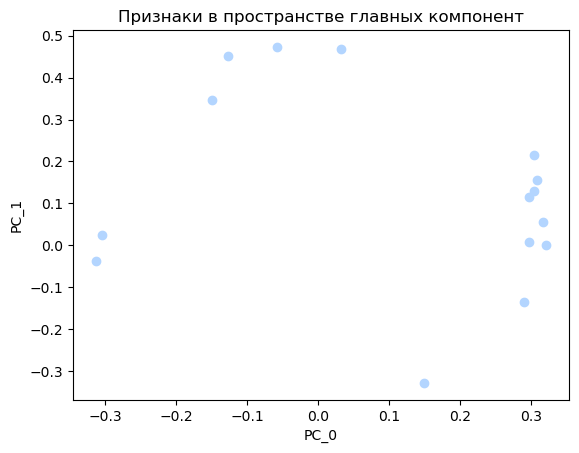

In [51]:
plt.scatter((pca.components_).T[:, 0], (pca.components_).T[:, 1], color='#b3d5ff')

plt.xlabel('PC_0')
plt.ylabel('PC_1')
plt.title('Признаки в пространстве главных компонент')

plt.show()

In [41]:
# Построение диаграммы биплот

def bp(score, coef, data_color, vect_color, labels=None):
    xs = score[:,0]     # первый столбец PC1
    ys = score[:,1]     # первый столбец PC2
    n = coef.shape[0]   # сколько компонент
    scalex = 1.0/(xs.max()-xs.min())
    scaley = 1.0/(ys.max()-ys.min())
    plt.scatter(xs * scalex, ys * scaley, s=50, color=data_color)

    for i in range(n):
        plt.arrow(0,0,coef[i,0],
                 coef[i,1], color=vect_color,
                 alpha=0.5)
        plt.text(coef[i,0]*1, coef[i,1]*1,
                labels[i],
                ha='center',
                va='center')

    plt.xlabel('PC{}'.format(1))
    plt.ylabel('PC{}'.format(2))

    plt.figure()

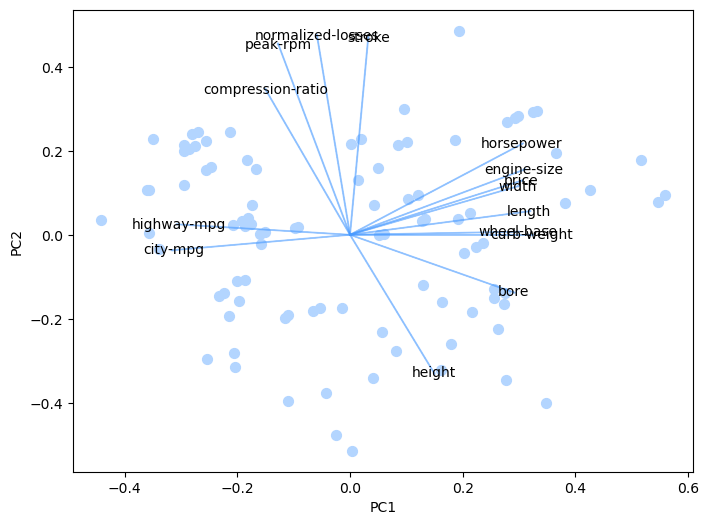

<Figure size 640x480 with 0 Axes>

In [42]:
plt.figure(figsize=(8, 6))

bp(score, pca.components_.T, data_color='#b3d5ff', vect_color='#499bff', labels=df.columns)

plt.show()

Можно заметить, что переменная PC1:
- Имеет сильную положительную зависимость с такими переменными, как horsepower, engine-size, width, length, curb-weight, bore, price
- Имеет сильную положительную зависимость с такими переменными, как highway-mpg, city-mpg (и это логично, чем мощнее, больше и дороже автомобиль, тем больше и быстрее расходует машина топливо, т.е. меньше миль на галлон приходится)
- Таким образом данная переменная отвечает за размер и мощность автомобиля, а также за экономичность (справа находятся большие, мощные и дорогие автомобили, слева наоборот)

Что касается переменной PC2:
- Имеет сильную положительную зависимость с переменными stroke, peak-rpm, compression-ratio, normalized-losses. Первые три переменые связаны с двигателем, можно предположить, эта переменная отвечает за тип двигателя

Исходя из анализа выше, дадим названия сжатым переменным:
- PC1 - класс автомобиля
- PC2 - тип двигателя


### Для удобства

| Переменная | Описание |
| :--- | :--- |
| **symboling** | Показатель страхового риска (от -3 до +3). Чем выше число, тем рискованнее автомобиль. |
| **normalized-losses** | Относительная средняя выплата по страховке за год. |
| **make** | Марка автомобиля (Toyota, Nissan, Volvo и др.). |
| **fuel-type** | Тип топлива (gas — бензин, diesel — дизель). |
| **aspiration** | Тип впуска двигателя (std — стандартный, turbo — турбонаддув). |
| **num-of-doors** | Количество дверей (two — две, four — четыре). |
| **body-style** | Тип кузова (sedan, hatchback, wagon, hardtop, convertible). |
| **drive-wheels** | Привод (fwd — передний, rwd — задний, 4wd — полный). |
| **engine-location** | Расположение двигателя (front — спереди, rear — сзади). |
| **wheel-base** | Колесная база (расстояние между осями колес). |
| **length, width, height** | Габариты автомобиля (длина, ширина, высота). |
| **curb-weight** | Снаряженная масса (вес без пассажиров). |
| **engine-type** | Тип конструкции двигателя (ohc, ohcv, dohc и др.). |
| **num-of-cylinders** | Количество цилиндров. |
| **engine-size** | Объем двигателя. |
| **fuel-system** | Система подачи топлива (mpfi, 2bbl, idi и др.). |
| **bore / stroke** | Диаметр цилиндра и ход поршня. |
| **compression-ratio** | Степень сжатия. |
| **horsepower** | Мощность в лошадиных силах. |
| **peak-rpm** | Обороты двигателя при пиковой мощности. |
| **city / highway-mpg** | Расход топлива в городе и на шоссе (миль на галлон). |
| **price** | **Целевая переменная:** Стоимость автомобиля. |